# M3DSynth Dataset - Comprehensive Analysis

## Dataset Structure

The **M3DSynth** dataset is designed for **medical deepfake detection** on 3D lung CT scans (LIDC-IDRI).

### CSV Files and Their Roles

| File | Description |
|------|-------------|
| `data.csv` | Main table: each row is a volume with the **nodule coordinates (z,y,x)** (anomaly location) |
| `sets.csv` | Assigns each patient (orig_id) to train/valid/test |
| `LIDC.csv` | Original DICOM metadata: spacing, original path |
| `centers.csv` | Crop centers for testing (per volume × modality) — used for deterministic cropping |

### Manipulation Types

- **`inj` (injection)**: a cancerous nodule is **injected** (added) into the CT scan where none existed
- **`rem` (removal)**: a real cancerous nodule is **removed** (erased) from the CT scan

### Generative Modalities (`mod`)

- **`real`**: original scan (unmanipulated)
- **`pix2pix`**: manipulated with Pix2Pix network
- **`diffusion`**: manipulated with Diffusion model
- **`cycle`**: manipulated with CycleGAN

### Coordinates in `data.csv`

The columns `coord_z`, `coord_y`, `coord_x` indicate the **nodule position** in the 512×512×Z volume:
- For **inj+real**: where the original nodule is located (to be injected in fake versions)
- For **rem+real**: where the nodule was before being removed in fake versions
- For **fake (pix2pix/cycle/diffusion)**: same position — the manipulated region

### On-Disk Structure

```
M3DSynth/
├── real/scan/{img_id}/slide0000.tiff, slide0001.tiff, ...   (scan only, no labels)
├── cycle/scan/{img_id}/...  +  cycle/label/{img_id}/...     (scan + binary mask)
├── pix2pix/scan/{img_id}/... + pix2pix/label/{img_id}/...
├── diffusion/scan/{img_id}/... + diffusion/label/{img_id}/...
```

**Labels** (binary masks) exist only for fake versions and indicate **exactly which voxels were manipulated**.

In [11]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
from PIL import Image

# Add project path
sys.path.insert(0, '/home/opontorno/projects/MedForensics')
from config import DATA_DIR
from medforensics.utils.tiff_utils import (
    load_tiff_scan, load_slice_tiff_scan, get_shape_tiff_scan,
    get_percentile_tiff_scan, apply_percentile
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style("whitegrid")

print(f"DATA_DIR: {DATA_DIR}")

DATA_DIR: /mnt/lguarnera_group/opontorno/med_datasets/M3DSynth


## 1. Loading and Metadata Overview

In [12]:
# Load CSV files
data = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
sets = pd.read_csv(os.path.join(DATA_DIR, 'sets.csv'))
centers = pd.read_csv(os.path.join(DATA_DIR, 'centers.csv'))
lidc = pd.read_csv(os.path.join(DATA_DIR, 'LIDC.csv'))

# Full merge
tab = data.merge(sets, on='orig_id').merge(centers, on=['img_id', 'mod'], how='left')

print(f"Total rows in data.csv: {len(data)}")
print(f"After merge with sets + centers: {len(tab)}")
print(f"\nResulting columns: {list(tab.columns)}")
print(f"\n--- First 10 records ---")
tab.head(10)

Total rows in data.csv: 11828
After merge with sets + centers: 11828

Resulting columns: ['img_id', 'ty', 'mod', 'orig_id', 'sdir_id', 'coord_z', 'coord_y', 'coord_x', 'set', 'center_test_z', 'center_test_y', 'center_test_x']

--- First 10 records ---


,img_id,ty,mod,orig_id,sdir_id,coord_z,coord_y,coord_x,set,center_test_z,center_test_y,center_test_x
0,rem_1,rem,real,LIDC-IDRI-0003,3000611,57,198,308,train,NaN,NaN,NaN
1,rem_10,rem,real,LIDC-IDRI-0014,3000562,40,276,357,train,NaN,NaN,NaN
2,rem_100,rem,real,LIDC-IDRI-0124,3,48,287,393,train,NaN,NaN,NaN
3,rem_1000,rem,real,LIDC-IDRI-0884,2,54,248,375,train,NaN,NaN,NaN
4,rem_1001,rem,real,LIDC-IDRI-0886,30036,33,185,265,valid,NaN,NaN,NaN
5,rem_1002,rem,real,LIDC-IDRI-0888,30015,114,350,180,train,NaN,NaN,NaN
6,rem_1003,rem,real,LIDC-IDRI-0892,5916,75,182,140,valid,NaN,NaN,NaN
7,rem_1005,rem,real,LIDC-IDRI-0892,5916,55,170,372,valid,NaN,NaN,NaN
8,rem_1007,rem,real,LIDC-IDRI-0893,30028,187,335,168,train,NaN,NaN,NaN
9,rem_1009,rem,real,LIDC-IDRI-0902,32242,383,349,303,train,NaN,NaN,NaN


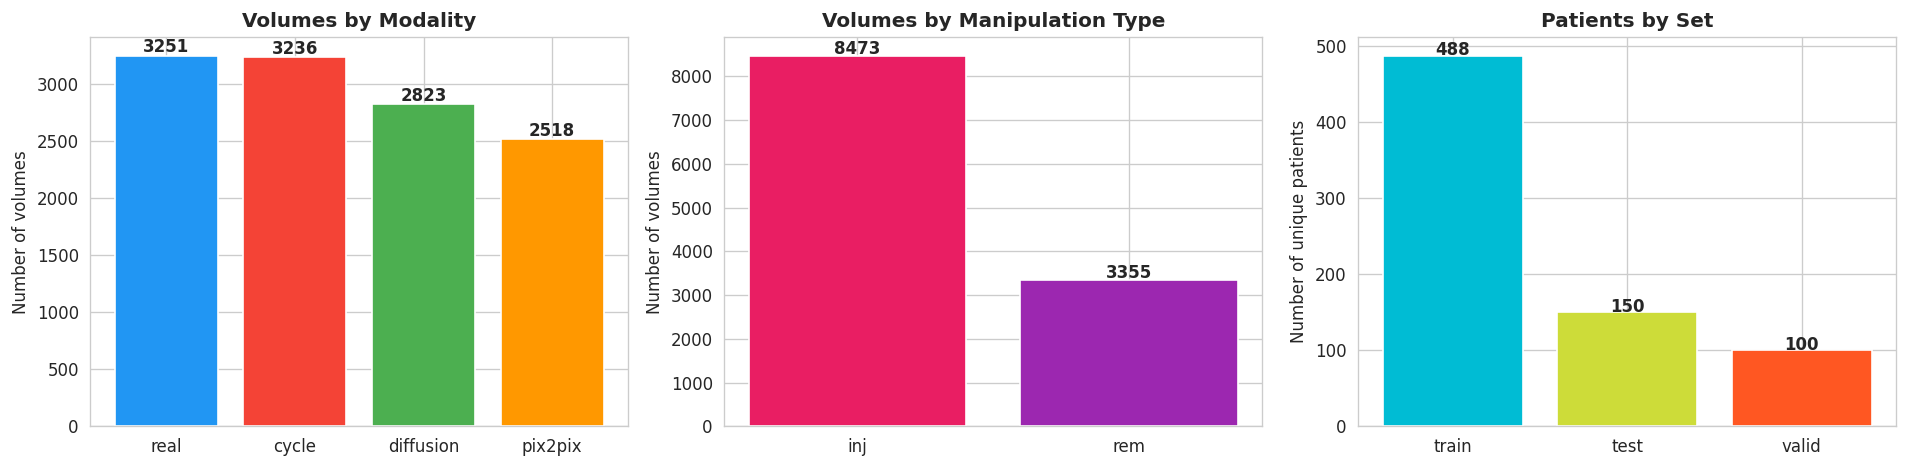

In [13]:
# --- Distribution by type, modality and set ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) By modality
mod_counts = tab['mod'].value_counts()
colors_mod = {'real': '#2196F3', 'pix2pix': '#FF9800', 'diffusion': '#4CAF50', 'cycle': '#F44336'}
axes[0].bar(mod_counts.index, mod_counts.values, color=[colors_mod.get(m, '#999') for m in mod_counts.index])
axes[0].set_title('Volumes by Modality', fontweight='bold')
axes[0].set_ylabel('Number of volumes')
for i, v in enumerate(mod_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# 2) By type (inj/rem)
ty_counts = tab['ty'].value_counts()
colors_ty = {'inj': '#E91E63', 'rem': '#9C27B0'}
axes[1].bar(ty_counts.index, ty_counts.values, color=[colors_ty.get(t, '#999') for t in ty_counts.index])
axes[1].set_title('Volumes by Manipulation Type', fontweight='bold')
axes[1].set_ylabel('Number of volumes')
for i, v in enumerate(ty_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

# 3) By set
set_counts = tab.groupby('orig_id').first().reset_index()['set'].value_counts()
axes[2].bar(set_counts.index, set_counts.values, color=['#00BCD4', '#CDDC39', '#FF5722'])
axes[2].set_title('Patients by Set', fontweight='bold')
axes[2].set_ylabel('Number of unique patients')
for i, v in enumerate(set_counts.values):
    axes[2].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# --- Cross-tabulation type × modality ---
ct = pd.crosstab(tab['ty'], tab['mod'], margins=True)
print("Distribution type × modality:")
print(ct)
print("\n--- Distribution type × modality × set ---")
ct2 = pd.crosstab([tab['set'], tab['ty']], tab['mod'], margins=True)
print(ct2)

Distribution type × modality:
mod  cycle  diffusion  pix2pix  real    All
ty                                         
inj   2220       2009     2009  2235   8473
rem   1016        814      509  1016   3355
All   3236       2823     2518  3251  11828

--- Distribution type × modality × set ---
mod        cycle  diffusion  pix2pix  real    All
set   ty                                         
test  inj    499        426      426   499   1850
      rem    294        246      139   294    973
train inj   1247       1221     1221  1253   4942
      rem    534        486      316   534   1870
valid inj    474        362      362   483   1681
      rem    188         82       54   188    512
All         3236       2823     2518  3251  11828


## 2. Spatial Distribution of Nodules (Coordinates)

The coordinates `coord_z`, `coord_y`, `coord_x` indicate the nodule center in the original 512×512×Z volume.
We analyze how they are distributed in space, broken down by type (inj/rem).

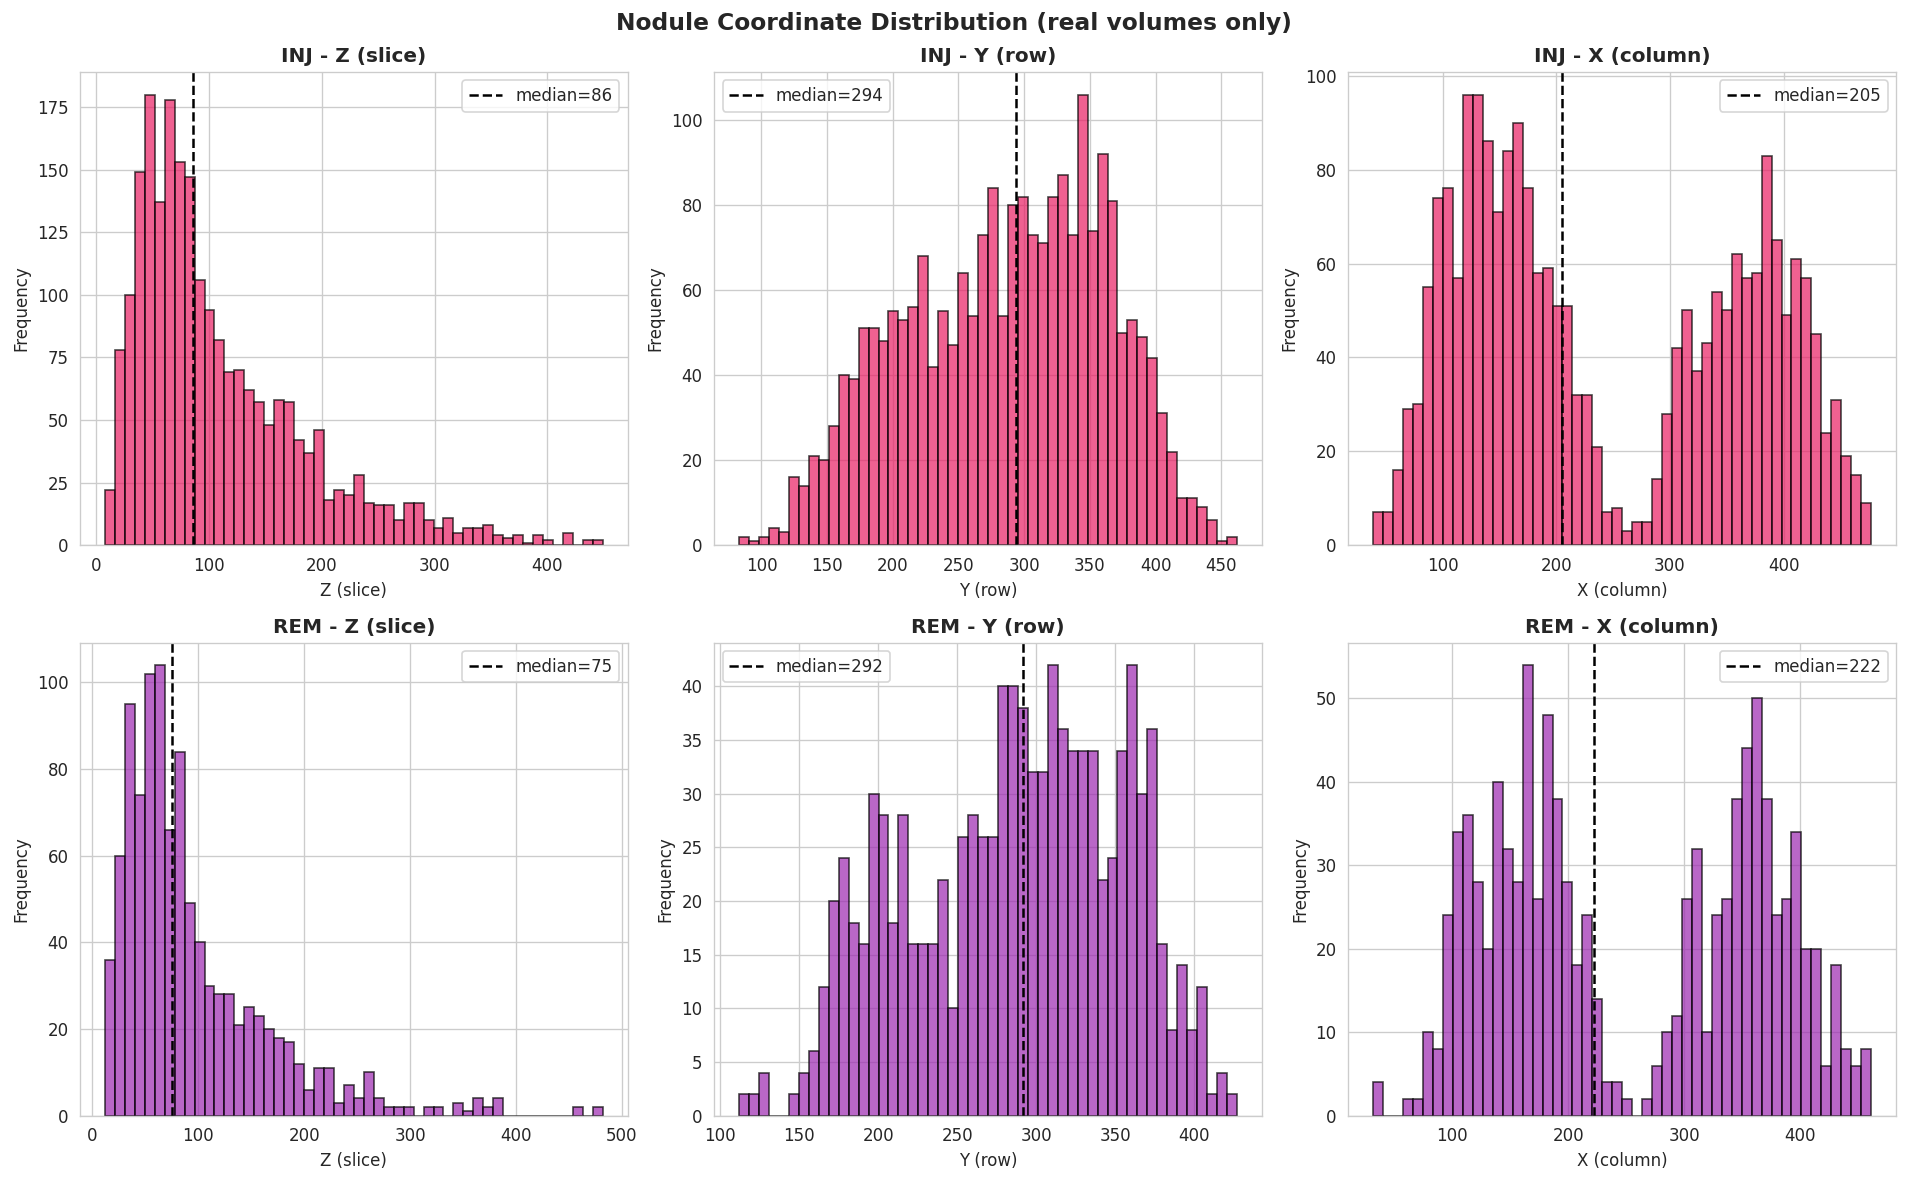


--- Coordinate statistics (real only) ---

INJ (2235 volumes):
       coord_z  coord_y  coord_x
count   2235.0   2235.0   2235.0
mean     110.3    286.6    245.2
std       77.2     75.5    121.6
min        8.0     83.0     39.0
25%       54.0    225.5    137.0
50%       86.0    294.0    205.0
75%      148.0    347.0    366.0
max      449.0    462.0    477.0

REM (1016 volumes):
       coord_z  coord_y  coord_x
count   1016.0   1016.0   1016.0
mean      95.6    286.9    254.3
std       71.6     66.6    110.9
min       12.0    112.0     32.0
25%       47.0    234.0    155.8
50%       75.0    291.5    222.0
75%      121.2    338.2    359.0
max      482.0    427.0    461.0


In [15]:
# --- Spatial distribution of nodule coordinates ---
# Use only 'real' rows to get nodule coordinates without per-architecture duplicates
tab_real = tab[tab['mod'] == 'real']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row_idx, ty in enumerate(['inj', 'rem']):
    subset = tab_real[tab_real['ty'] == ty]
    
    for col_idx, (coord, label) in enumerate([('coord_z', 'Z (slice)'), 
                                                ('coord_y', 'Y (row)'), 
                                                ('coord_x', 'X (column)')]):
        ax = axes[row_idx, col_idx]
        ax.hist(subset[coord], bins=50, alpha=0.7, edgecolor='black',
                color='#E91E63' if ty == 'inj' else '#9C27B0')
        ax.set_title(f'{ty.upper()} - {label}', fontweight='bold')
        ax.set_xlabel(label)
        ax.set_ylabel('Frequency')
        ax.axvline(subset[coord].median(), color='black', linestyle='--', label=f'median={subset[coord].median():.0f}')
        ax.legend()

plt.suptitle('Nodule Coordinate Distribution (real volumes only)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n--- Coordinate statistics (real only) ---")
for ty in ['inj', 'rem']:
    subset = tab_real[tab_real['ty'] == ty]
    print(f"\n{ty.upper()} ({len(subset)} volumes):")
    print(subset[['coord_z', 'coord_y', 'coord_x']].describe().round(1))

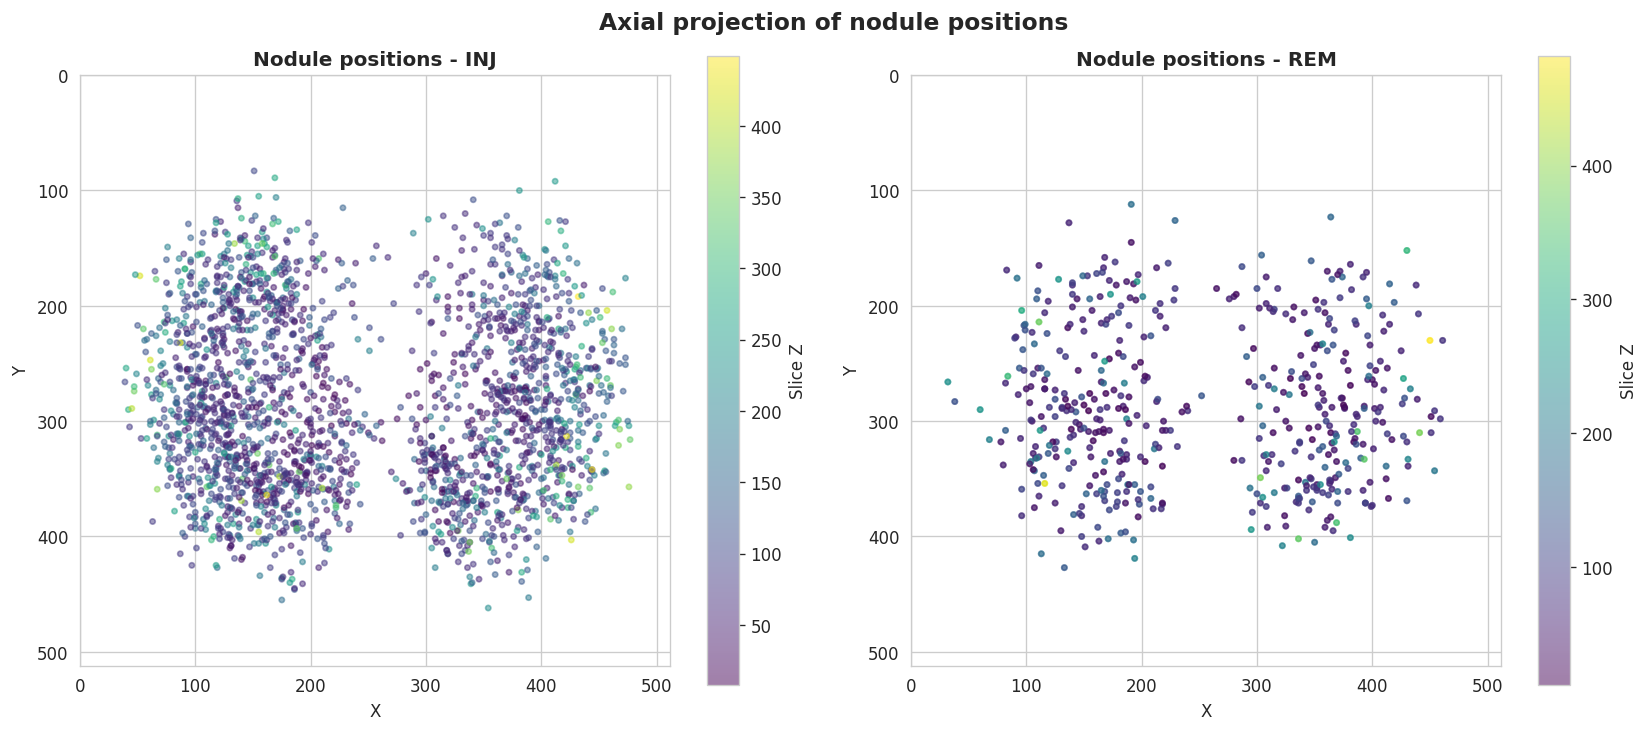

In [16]:
# --- 2D scatter of nodule positions (axial projection) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, ty in enumerate(['inj', 'rem']):
    subset = tab_real[tab_real['ty'] == ty]
    sc = axes[idx].scatter(subset['coord_x'], subset['coord_y'], 
                           c=subset['coord_z'], cmap='viridis', alpha=0.5, s=10)
    axes[idx].set_xlim(0, 512)
    axes[idx].set_ylim(512, 0)  # y inverted as in images
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('Y')
    axes[idx].set_title(f'Nodule positions - {ty.upper()}', fontweight='bold')
    axes[idx].set_aspect('equal')
    plt.colorbar(sc, ax=axes[idx], label='Slice Z')

plt.suptitle('Axial projection of nodule positions', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Volume Dimensions and Spacing

We analyze the volume dimensions (number of slices) and the original DICOM spacing to understand geometric variability.

Measuring volume depth: 100%|██████████| 200/200 [00:00<00:00, 1093.50it/s]


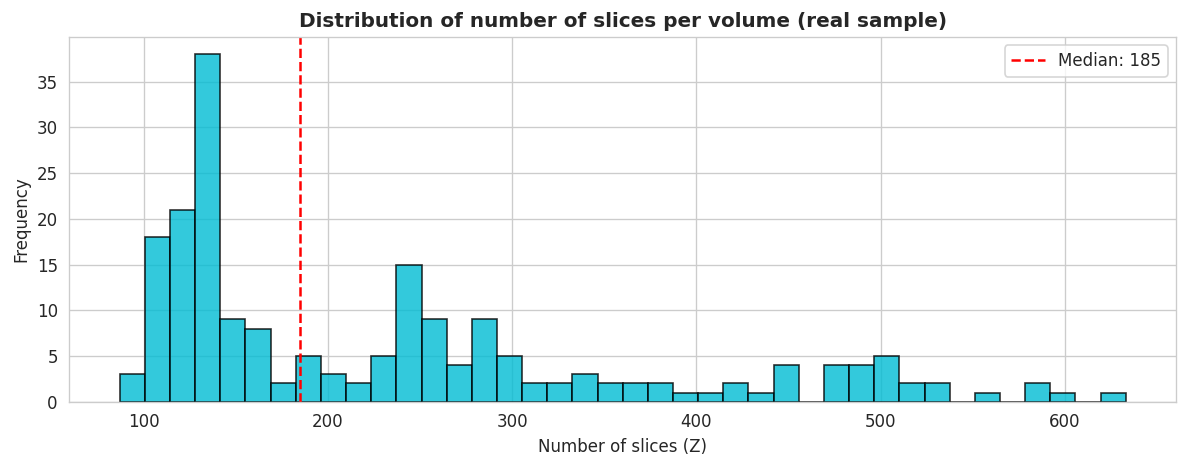


Volume depth statistics:
count    200.0
mean     234.0
std      133.1
min       87.0
25%      132.5
50%      185.0
75%      290.0
max      633.0
dtype: float64


In [17]:
# --- Volume dimensions (number of slices) from a sample ---
# Measure the number of slices in a sample of real volumes
sample_ids = tab_real['img_id'].unique()
np.random.seed(42)
sample_ids_sub = np.random.choice(sample_ids, min(200, len(sample_ids)), replace=False)

volume_depths = {}
for img_id in tqdm(sample_ids_sub, desc="Measuring volume depth"):
    scan_dir = os.path.join(DATA_DIR, 'real', 'scan', img_id)
    if os.path.isdir(scan_dir):
        shape = get_shape_tiff_scan(scan_dir)
        volume_depths[img_id] = shape[0]

depths = pd.Series(volume_depths)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(depths, bins=40, edgecolor='black', color='#00BCD4', alpha=0.8)
ax.set_xlabel('Number of slices (Z)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of number of slices per volume (real sample)', fontweight='bold')
ax.axvline(depths.median(), color='red', linestyle='--', label=f'Median: {depths.median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nVolume depth statistics:")
print(depths.describe().round(1))

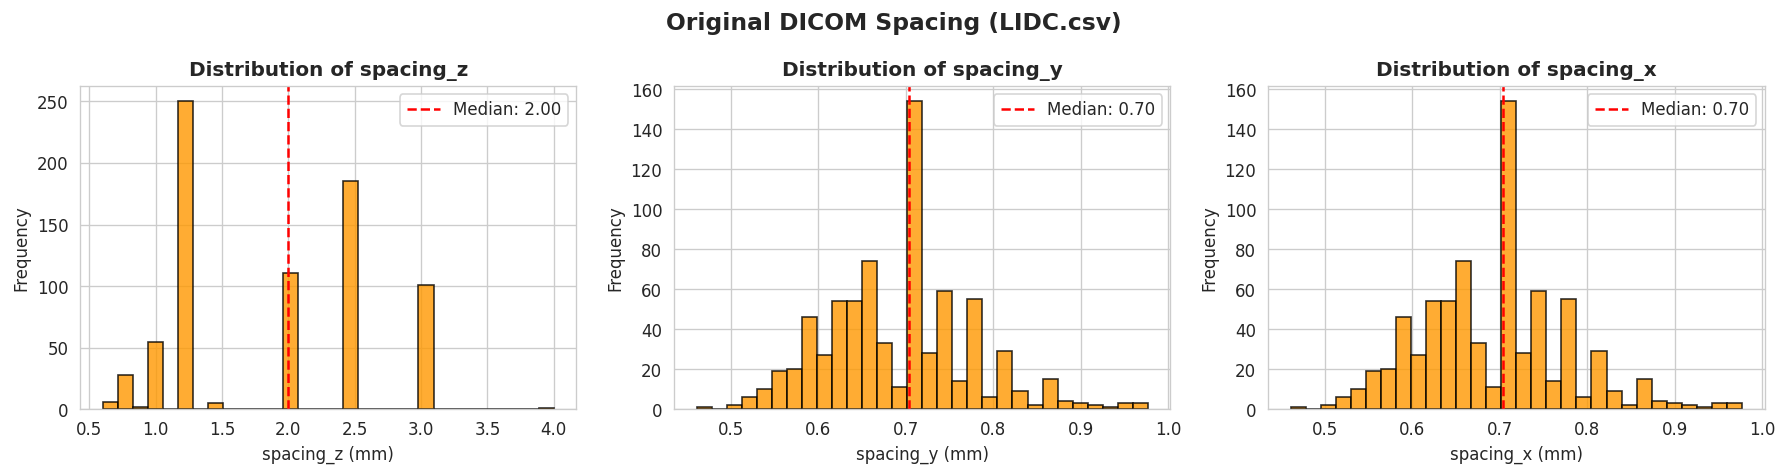


Spacing Statistics:
       spacing_z  spacing_y  spacing_x
count    744.000    744.000    744.000
mean       1.872      0.691      0.691
std        0.728      0.083      0.083
min        0.600      0.461      0.461
25%        1.250      0.633      0.633
50%        2.000      0.703      0.703
75%        2.500      0.742      0.742
max        4.000      0.977      0.977


In [18]:
# --- Spacing DICOM ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(['spacing_z', 'spacing_y', 'spacing_x']):
    axes[idx].hist(lidc[col], bins=30, edgecolor='black', color='#FF9800', alpha=0.8)
    axes[idx].set_xlabel(f'{col} (mm)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].axvline(lidc[col].median(), color='red', linestyle='--', 
                      label=f'Median: {lidc[col].median():.2f}')
    axes[idx].legend()

plt.suptitle('Original DICOM Spacing (LIDC.csv)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\nSpacing Statistics:")
print(lidc[['spacing_z', 'spacing_y', 'spacing_x']].describe().round(3))

## 4. Visual Comparison: Real vs Fake (by architecture)

We display the same slice from the real volume and the 3 fake versions, along with their manipulation masks.

=== INJECTION EXAMPLES ===


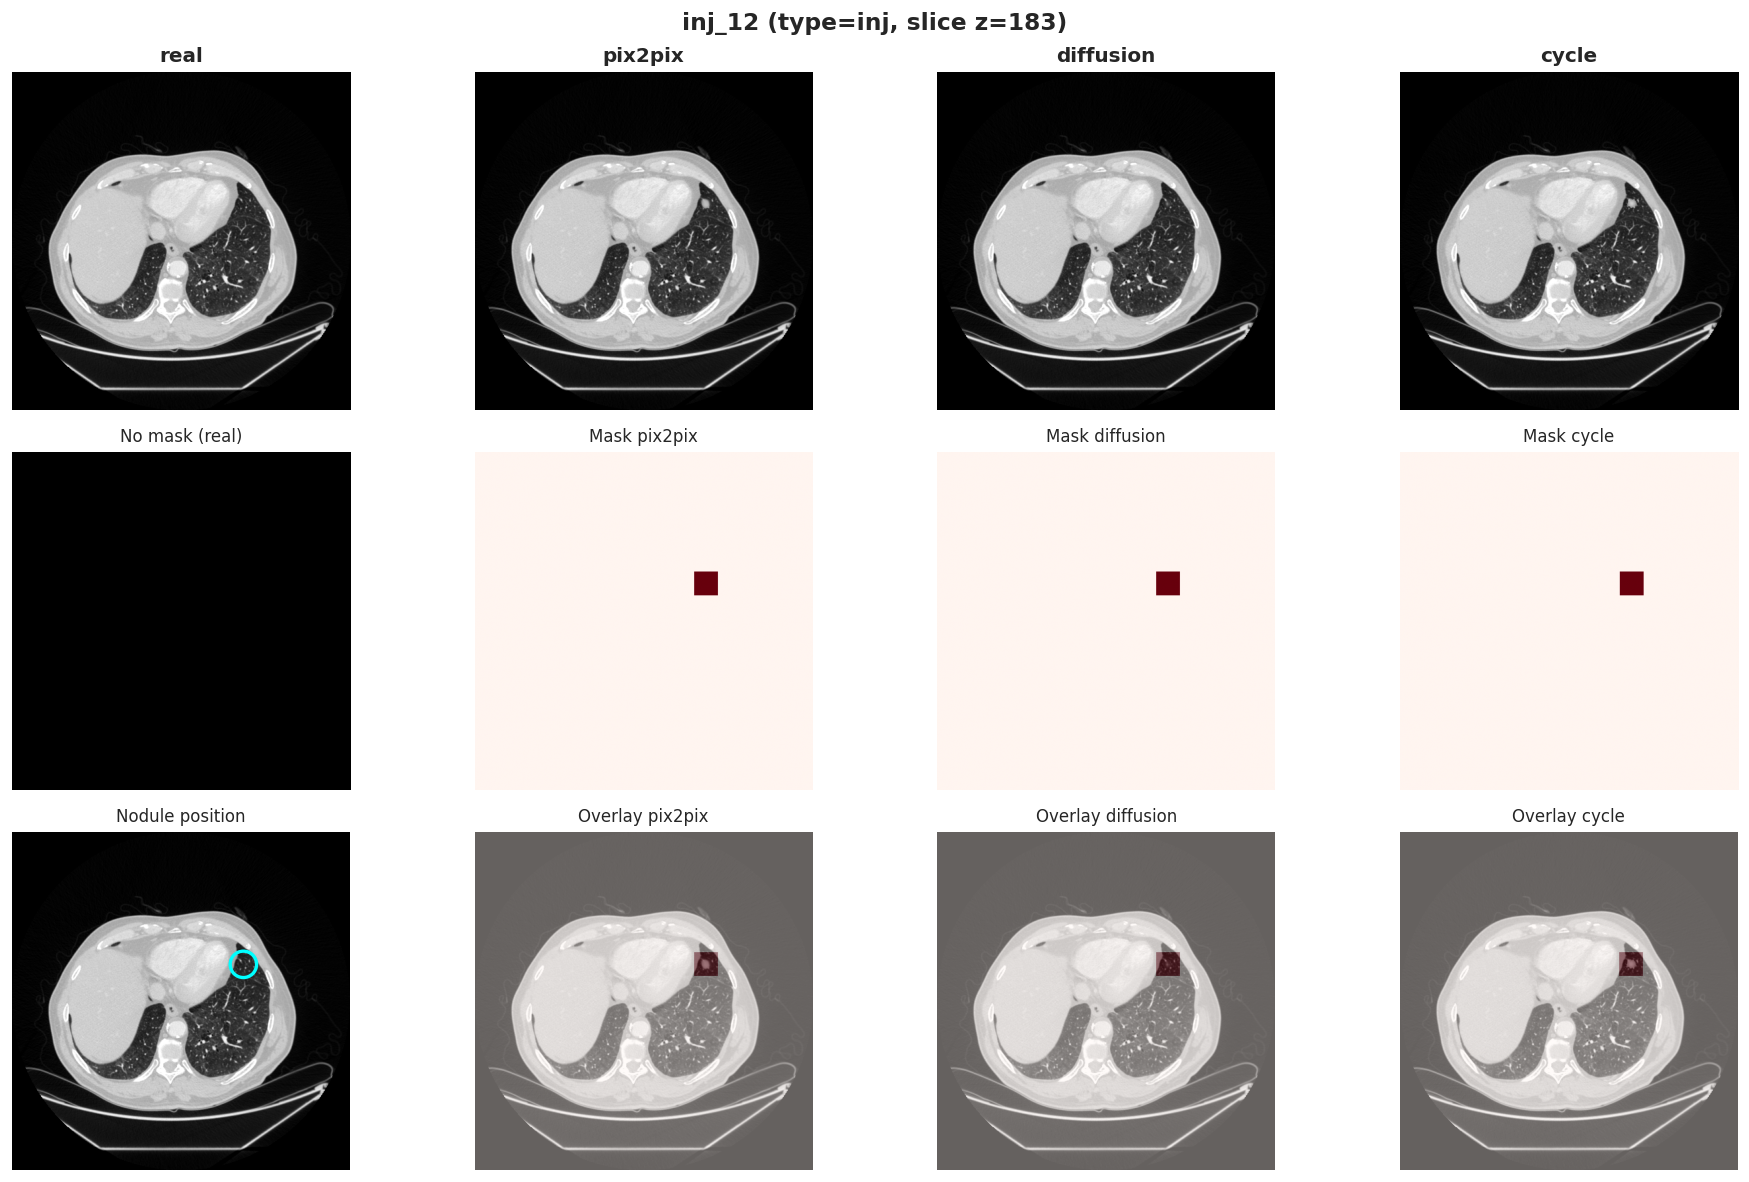


=== REMOVAL EXAMPLES ===


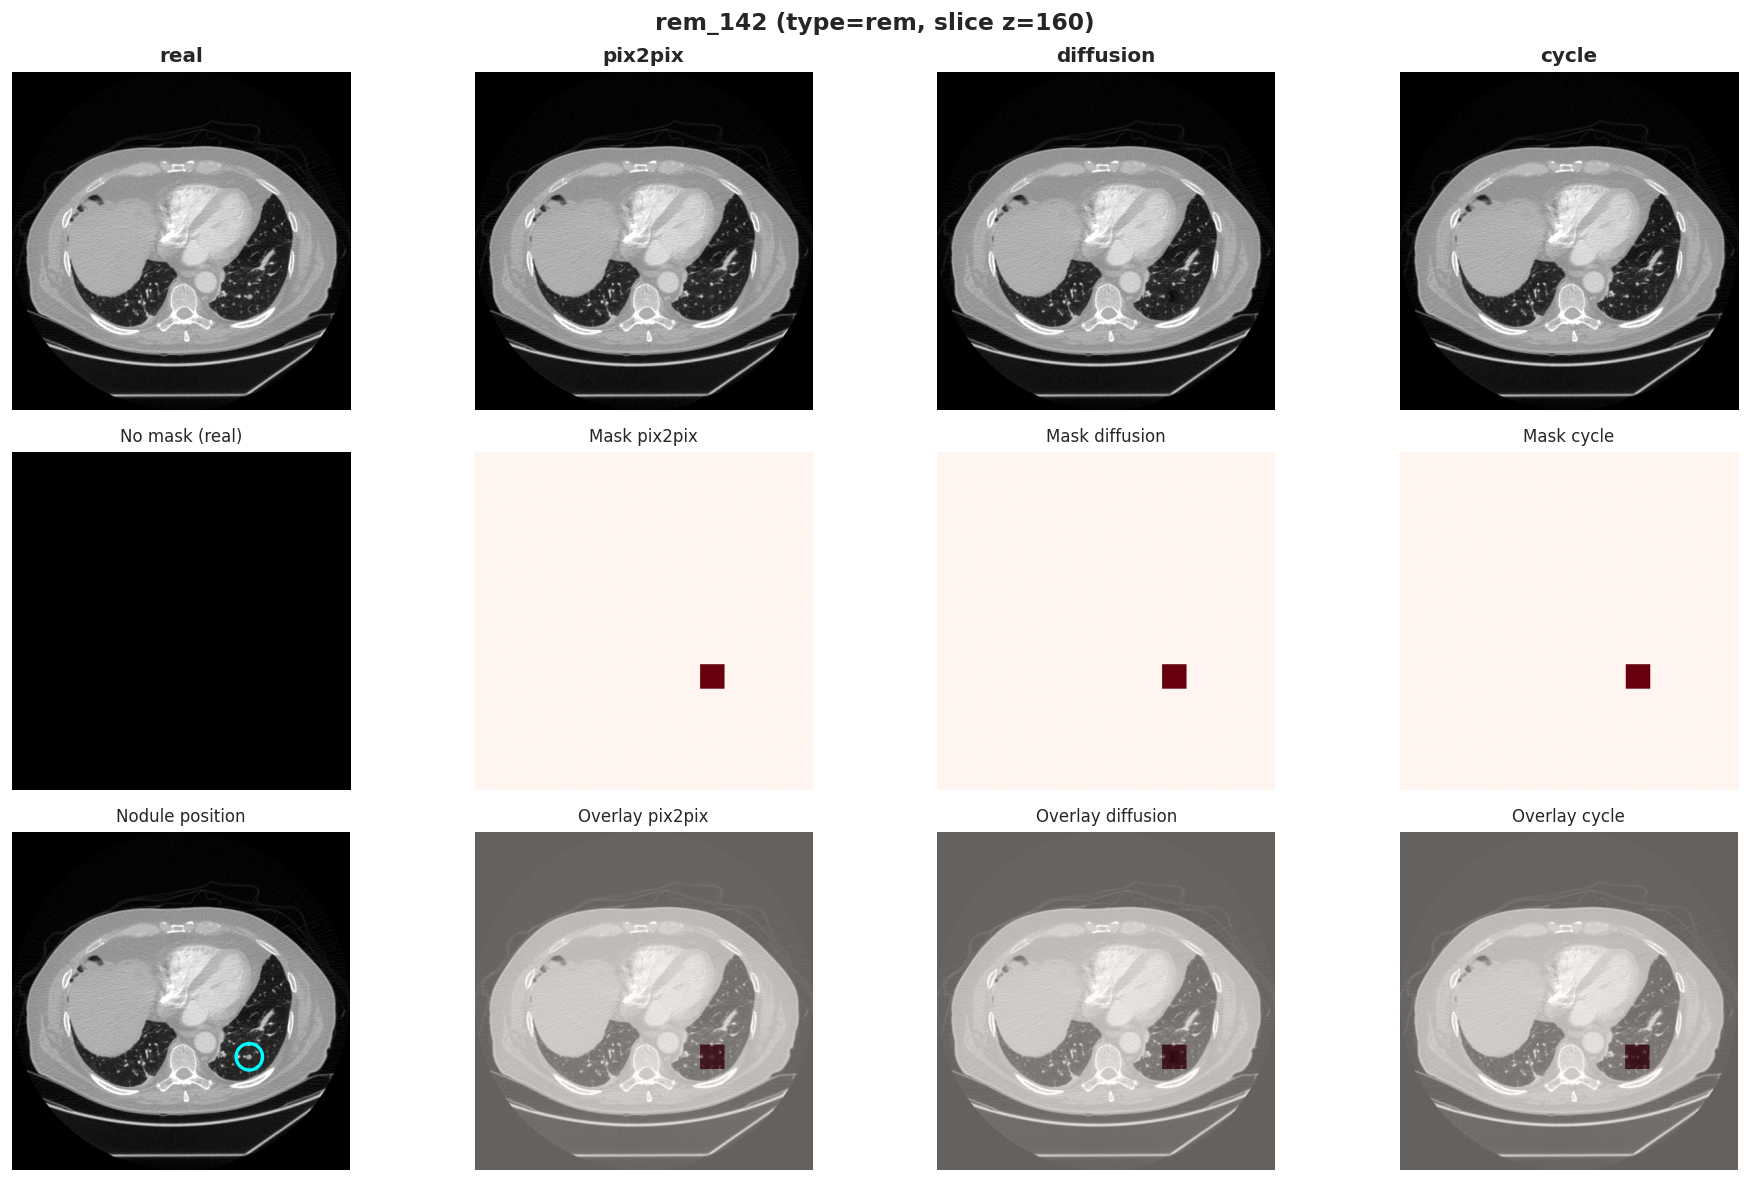

In [19]:
def show_comparison(img_id, slice_z=None, list_mod=['real', 'pix2pix', 'diffusion', 'cycle']):
    """
    Show the same slice across all modalities with their respective masks.
    If slice_z is None, uses coord_z from the dataframe.
    """
    row = data[data['img_id'] == img_id].iloc[0]
    if slice_z is None:
        slice_z = int(row['coord_z'])
    ty = row['ty']
    
    n_mod = len(list_mod)
    fig, axes = plt.subplots(3, n_mod, figsize=(4 * n_mod, 10))
    
    for idx, mod in enumerate(list_mod):
        scan_dir = os.path.join(DATA_DIR, mod, 'scan', img_id)
        if not os.path.isdir(scan_dir):
            continue
        
        shape = get_shape_tiff_scan(scan_dir)
        z = min(max(slice_z, 0), shape[0] - 1)
        
        scan = load_slice_tiff_scan(scan_dir, shape, np.uint16, z, z + 1)[0]
        low, high = get_percentile_tiff_scan(scan_dir, np.uint16)
        scan_norm = apply_percentile(np.float32(scan), low, high)
        
        axes[0, idx].imshow(scan_norm, cmap='gray', clim=[0, 1])
        axes[0, idx].set_title(f'{mod}', fontweight='bold', fontsize=12)
        axes[0, idx].axis('off')
        
        # Mask (fake only)
        if mod != 'real':
            mask_dir = os.path.join(DATA_DIR, mod, 'label', img_id)
            if os.path.isdir(mask_dir):
                mask = load_slice_tiff_scan(mask_dir, shape, np.bool_, z, z + 1)[0]
                axes[1, idx].imshow(mask, cmap='Reds', clim=[0, 1])
                axes[1, idx].set_title(f'Mask {mod}', fontsize=10)
                
                # Overlay: scan + mask
                axes[2, idx].imshow(scan_norm, cmap='gray', clim=[0, 1])
                axes[2, idx].imshow(mask, cmap='Reds', alpha=0.4)
                axes[2, idx].set_title(f'Overlay {mod}', fontsize=10)
            else:
                axes[1, idx].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[1, idx].transAxes)
                axes[2, idx].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[2, idx].transAxes)
        else:
            # For real, show the nodule location with a circle
            axes[1, idx].imshow(np.zeros_like(scan_norm), cmap='gray')
            axes[1, idx].set_title('No mask (real)', fontsize=10)
            axes[2, idx].imshow(scan_norm, cmap='gray', clim=[0, 1])
            # Mark the nodule position
            circle = plt.Circle((row['coord_x'], row['coord_y']), 20, color='cyan', fill=False, linewidth=2)
            axes[2, idx].add_patch(circle)
            axes[2, idx].set_title('Nodule position', fontsize=10)
        
        axes[1, idx].axis('off')
        axes[2, idx].axis('off')
    
    axes[0, 0].set_ylabel('Scan', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Mask', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Overlay', fontsize=12, fontweight='bold')
    
    fig.suptitle(f'{img_id} (type={ty}, slice z={z})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show some injection and removal examples
print("=== INJECTION EXAMPLES ===")
show_comparison('inj_12')

print("\n=== REMOVAL EXAMPLES ===")
show_comparison('rem_142')

## 5. Intensity Analysis by Architecture

We compare voxel intensity distributions in the nodule region between real and the different generative architectures.

In [20]:
def extract_nodule_region(img_id, mod, coord_z, coord_y, coord_x, half_size=32):
    """
    Extract a 3D region around the nodule (cube of side 2*half_size).
    Returns the normalized region.
    """
    scan_dir = os.path.join(DATA_DIR, mod, 'scan', img_id)
    if not os.path.isdir(scan_dir):
        return None
    
    shape = get_shape_tiff_scan(scan_dir)
    low, high = get_percentile_tiff_scan(scan_dir, np.uint16)
    
    z_start = max(0, coord_z - half_size)
    z_end = min(shape[0], coord_z + half_size)
    
    region = load_slice_tiff_scan(scan_dir, shape, np.uint16, z_start, z_end)
    
    y_start = max(0, coord_y - half_size)
    y_end = min(shape[1], coord_y + half_size)
    x_start = max(0, coord_x - half_size)
    x_end = min(shape[2], coord_x + half_size)
    
    region = region[:, y_start:y_end, x_start:x_end]
    region = apply_percentile(np.float32(region), low, high)
    return region


def extract_mask_region(img_id, mod, coord_z, coord_y, coord_x, half_size=32):
    """Extract the mask in the nodule region."""
    if mod == 'real':
        return None
    mask_dir = os.path.join(DATA_DIR, mod, 'label', img_id)
    if not os.path.isdir(mask_dir):
        return None
    scan_dir = os.path.join(DATA_DIR, mod, 'scan', img_id)
    shape = get_shape_tiff_scan(scan_dir)

    z_start = max(0, coord_z - half_size)
    z_end = min(shape[0], coord_z + half_size)
    
    mask = load_slice_tiff_scan(mask_dir, shape, np.bool_, z_start, z_end)
    
    y_start = max(0, coord_y - half_size)
    y_end = min(shape[1], coord_y + half_size)
    x_start = max(0, coord_x - half_size)
    x_end = min(shape[2], coord_x + half_size)
    
    mask = mask[:, y_start:y_end, x_start:x_end]
    return mask

print("Region extraction functions defined.")

Region extraction functions defined.


In [21]:
# --- Sample for intensity analysis in the nodule region ---
# Take N volumes from the test set and analyze intensities by architecture
N_SAMPLES = 30
list_mod = ['real', 'pix2pix', 'diffusion', 'cycle']
HALF = 24

tab_test = tab[tab['set'] == 'test']
# Select only img_ids present in all modalities
img_ids_all = set(tab_test[tab_test['mod'] == 'real']['img_id'])
for mod in ['pix2pix', 'diffusion', 'cycle']:
    img_ids_all &= set(tab_test[tab_test['mod'] == mod]['img_id'])

img_ids_common = sorted(img_ids_all)
np.random.seed(42)
sample_ids = np.random.choice(img_ids_common, min(N_SAMPLES, len(img_ids_common)), replace=False)

# For each modality, collect statistics
intensity_data = {mod: {'means': [], 'stds': [], 'medians': [], 'all_pixels': []} for mod in list_mod}
mask_data = {mod: {'volumes': [], 'fractions': []} for mod in list_mod if mod != 'real'}

for img_id in tqdm(sample_ids, desc="Extracting features"):
    row = data[data['img_id'] == img_id].iloc[0]
    cz, cy, cx = int(row['coord_z']), int(row['coord_y']), int(row['coord_x'])
    
    for mod in list_mod:
        region = extract_nodule_region(img_id, mod, cz, cy, cx, HALF)
        if region is not None:
            intensity_data[mod]['means'].append(np.mean(region))
            intensity_data[mod]['stds'].append(np.std(region))
            intensity_data[mod]['medians'].append(np.median(region))
            intensity_data[mod]['all_pixels'].extend(region.flatten()[::10].tolist())
            
            if mod != 'real':
                mask = extract_mask_region(img_id, mod, cz, cy, cx, HALF)
                if mask is not None:
                    mask_data[mod]['volumes'].append(np.sum(mask))
                    mask_data[mod]['fractions'].append(np.mean(mask))

print(f"\nSample analyzed: {len(sample_ids)} volumes × {len(list_mod)} modalities")

Extracting features: 100%|██████████| 30/30 [12:41<00:00, 25.37s/it]


Sample analyzed: 30 volumes × 4 modalities


/tmp/ipykernel_1967199/1038753036.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=list_mod, patch_artist=True)
/tmp/ipykernel_1967199/1038753036.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(bp_data_std, labels=list_mod, patch_artist=True)
/tmp/ipykernel_1967199/1038753036.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax.boxplot(bp_data_vol, labels=fake_mods, patch_artist=True)


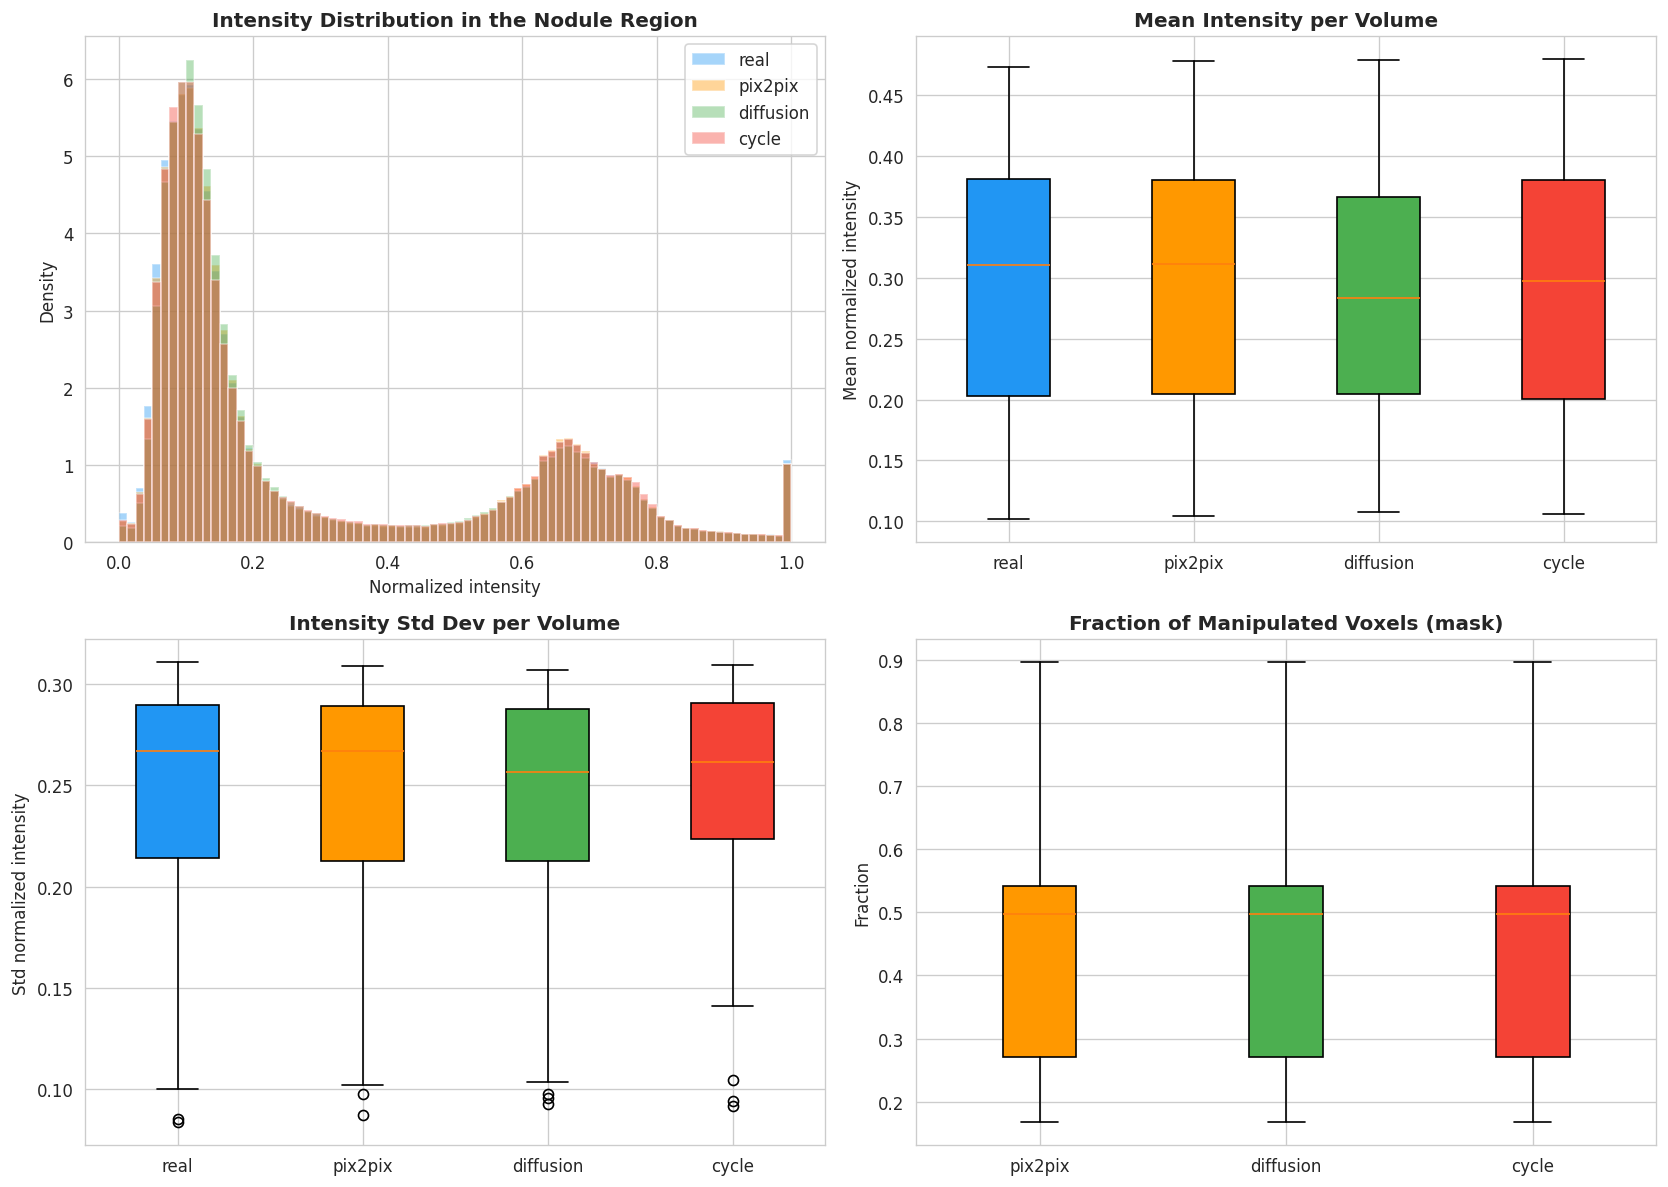

In [22]:
# --- Plot: Intensity distributions in the nodule region by architecture ---
colors = {'real': '#2196F3', 'pix2pix': '#FF9800', 'diffusion': '#4CAF50', 'cycle': '#F44336'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Overlay histogram of intensities
ax = axes[0, 0]
for mod in list_mod:
    ax.hist(intensity_data[mod]['all_pixels'], bins=80, alpha=0.4, 
            color=colors[mod], label=mod, density=True)
ax.set_title('Intensity Distribution in the Nodule Region', fontweight='bold')
ax.set_xlabel('Normalized intensity')
ax.set_ylabel('Density')
ax.legend()

# 2) Boxplot of mean intensity by architecture
ax = axes[0, 1]
bp_data = [intensity_data[mod]['means'] for mod in list_mod]
bp = ax.boxplot(bp_data, labels=list_mod, patch_artist=True)
for patch, mod in zip(bp['boxes'], list_mod):
    patch.set_facecolor(colors[mod])
ax.set_title('Mean Intensity per Volume', fontweight='bold')
ax.set_ylabel('Mean normalized intensity')

# 3) Boxplot of standard deviation by architecture
ax = axes[1, 0]
bp_data_std = [intensity_data[mod]['stds'] for mod in list_mod]
bp2 = ax.boxplot(bp_data_std, labels=list_mod, patch_artist=True)
for patch, mod in zip(bp2['boxes'], list_mod):
    patch.set_facecolor(colors[mod])
ax.set_title('Intensity Std Dev per Volume', fontweight='bold')
ax.set_ylabel('Std normalized intensity')

# 4) Manipulated mask volume by architecture
ax = axes[1, 1]
fake_mods = [m for m in list_mod if m != 'real']
bp_data_vol = [mask_data[mod]['fractions'] for mod in fake_mods]
bp3 = ax.boxplot(bp_data_vol, labels=fake_mods, patch_artist=True)
for patch, mod in zip(bp3['boxes'], fake_mods):
    patch.set_facecolor(colors[mod])
ax.set_title('Fraction of Manipulated Voxels (mask)', fontweight='bold')
ax.set_ylabel('Fraction')

plt.tight_layout()
plt.show()